In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

native_df = pd.read_csv('output_files/native/native.csv')
decoys_df = pd.read_csv('output_files/decoys/decoys.csv')
all_native_df = pd.read_csv('output_files/native/all_native.csv')

def add_ring_mean_columns(df, radius_col='radius', n_rings=10):
    for ring_id in range(1, n_rings + 1):
        # Valore medio del raggio dell'anello in Angstrom
        df[f'ring{ring_id}_mean_A'] = df[radius_col] * (ring_id - 0.5) / 10
    return df

native_df = add_ring_mean_columns(native_df)
decoys_df = add_ring_mean_columns(decoys_df)
all_native_df = add_ring_mean_columns(all_native_df)

native_labeled = native_df.copy()
native_labeled['dataset_label'] = 'native'

decoys_labeled = decoys_df.copy()
decoys_labeled['complex_name'] = decoys_labeled['complex_name'].astype(str).str.split('-').str[0].str[:4]
decoys_labeled['dataset_label'] = 'decoy'

tot_df = pd.concat([native_labeled, decoys_labeled], ignore_index=True)

rings = [f'ring{n}_mean_A' for n in range(1, 11)]
zernike = [f'zernike_ring{n}_mean' for n in range(1, 11)]
zernike_sigma = [f'zernike_ring{n}_uncertainty' for n in range(1, 11)]
physical = [f'physical_ring{n}_mean' for n in range(1, 11)]
physical_sigma = [f'physical_ring{n}_uncertainty' for n in range(1, 11)]
roughness = [f'roughness_ring{n}' for n in range(1, 11)]

print('native_df:', native_df.shape)
print('decoys_df:', decoys_df.shape)
print('all_native_df:', all_native_df.shape)
print('tot_df:', tot_df.shape)

native_df: (3134, 73)
decoys_df: (3134, 73)
all_native_df: (3731, 73)
tot_df: (6268, 74)


In [5]:
import matplotlib.patches as mpatches


def build_rdf_long_df(df, metric_cols, dataset_label, radius_col='radius', n_rings=10, max_radius=50.0, bin_width=2.0):
    records = []
    n_bins = int(max_radius / bin_width)

    for _, row in df.iterrows():
        radius = pd.to_numeric(row.get(radius_col), errors='coerce')
        if not np.isfinite(radius) or radius <= 0:
            continue

        for ring_id in range(1, n_rings + 1):
            metric_value = pd.to_numeric(row.get(metric_cols[ring_id - 1]), errors='coerce')
            if not np.isfinite(metric_value):
                continue

            ring_radius = float(radius) * (ring_id - 0.5) / n_rings
            if not np.isfinite(ring_radius) or ring_radius < 0 or ring_radius > max_radius:
                continue

            bin_id = min(int(ring_radius // bin_width) + 1, n_bins)
            records.append({
                'dataset_label': dataset_label,
                'ring_id': ring_id,
                'rdf_value': float(metric_value),
                'ring_radius_A': ring_radius,
                'radius_bin_id': bin_id,
                'radius_bin_center_A': bin_id * bin_width - bin_width / 2.0,
            })

    return pd.DataFrame.from_records(records)


palette = {'native': '#1f77b4', 'decoy': '#d62728'}

physical_plot_df = pd.concat([
    build_rdf_long_df(native_df, physical, 'native'),
    build_rdf_long_df(decoys_df, physical, 'decoy'),
] , ignore_index=True)
zernike_plot_df = pd.concat([
    build_rdf_long_df(native_df, zernike, 'native'),
    build_rdf_long_df(decoys_df, zernike, 'decoy'),
] , ignore_index=True)
roughness_plot_df = pd.concat([
    build_rdf_long_df(native_df, roughness, 'native'),
    build_rdf_long_df(decoys_df, roughness, 'decoy'),
] , ignore_index=True)

print('physical_plot_df:', physical_plot_df.shape)
print('zernike_plot_df:', zernike_plot_df.shape)
print('roughness_plot_df:', roughness_plot_df.shape)

physical_plot_df: (62136, 6)
zernike_plot_df: (62136, 6)
roughness_plot_df: (62136, 6)


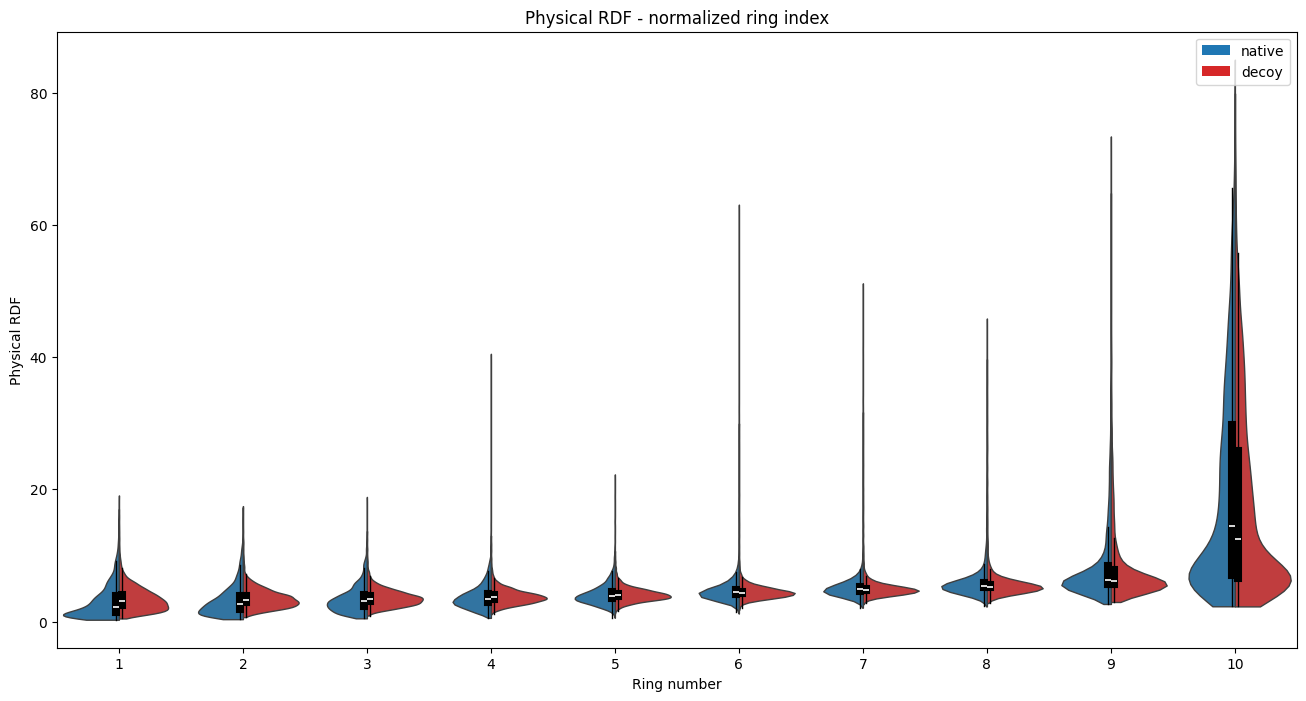

In [41]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.violinplot(
    data=physical_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    split=True,
    inner=None,
    cut=0,
    width=0.9,
    linewidth=1,
    ax=ax,
)
sns.boxplot(
    data=physical_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    width=0.10,
    whis=1.5,
    showfliers=False,
    showcaps=False,
    boxprops={'facecolor': 'black', 'edgecolor': 'black', 'zorder': 3},
    whiskerprops={'color': 'black', 'linewidth': 1.0},
    capprops={'color': 'black', 'linewidth': 0.0},
    medianprops={'color': 'white', 'linewidth': 1.2, 'zorder': 5},
    ax=ax,
)
legend = ax.get_legend()
if legend is not None:
    legend.remove()
ax.legend(handles=[
    mpatches.Patch(facecolor=palette['native'], label='native'),
    mpatches.Patch(facecolor=palette['decoy'], label='decoy'),
], title='')
ax.set_title('Physical RDF - normalized ring index')
ax.set_xlabel('Ring number')
ax.set_ylabel('Physical RDF')
fig.savefig('plots/physical_rdf_normalized.pdf', bbox_inches='tight')
plt.show()

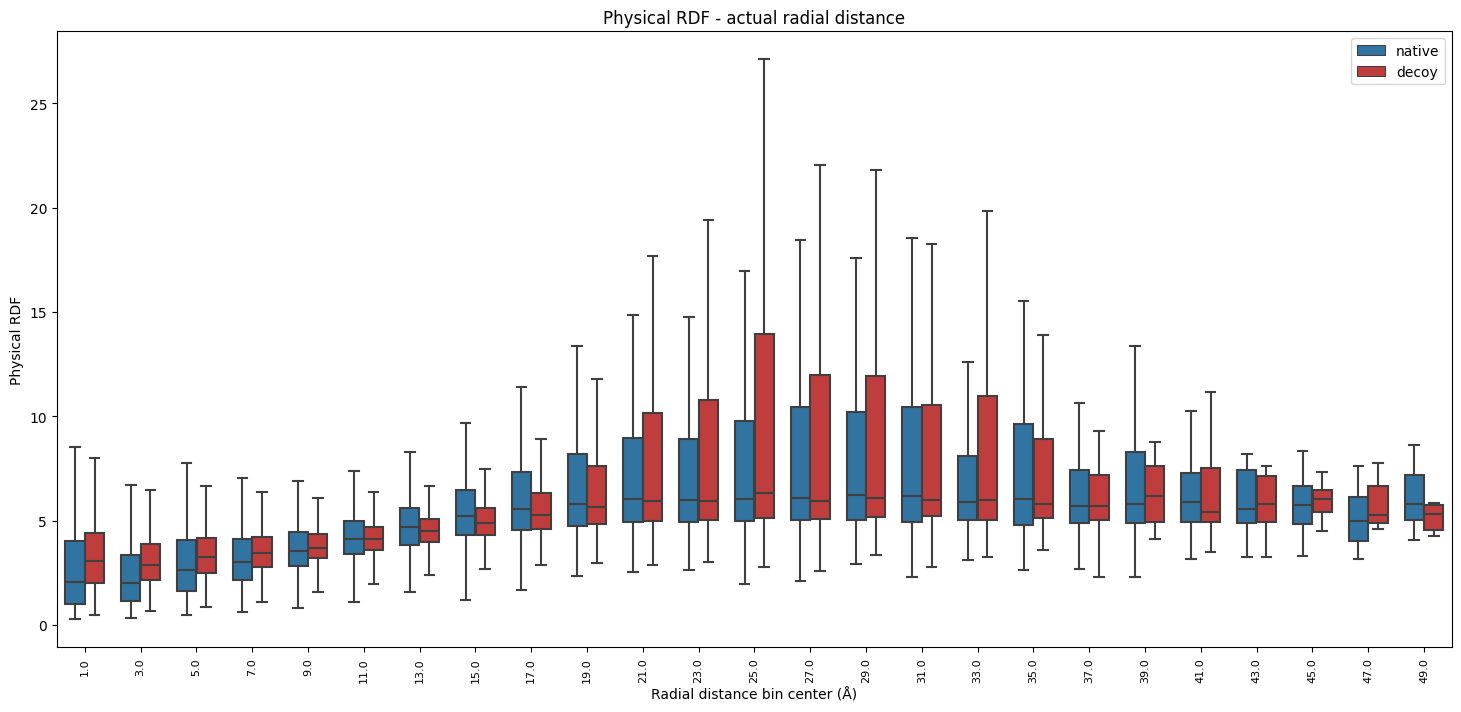

In [21]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=physical_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    showfliers=False,
    width=0.7,
    ax=ax,
)
ax.set_title('Physical RDF - actual radial distance')
ax.set_xlabel('Radial distance bin center (Å)')
ax.set_ylabel('Physical RDF')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.legend(title='')
fig.savefig('plots/physical_rdf_radial.pdf', bbox_inches='tight')
plt.show()

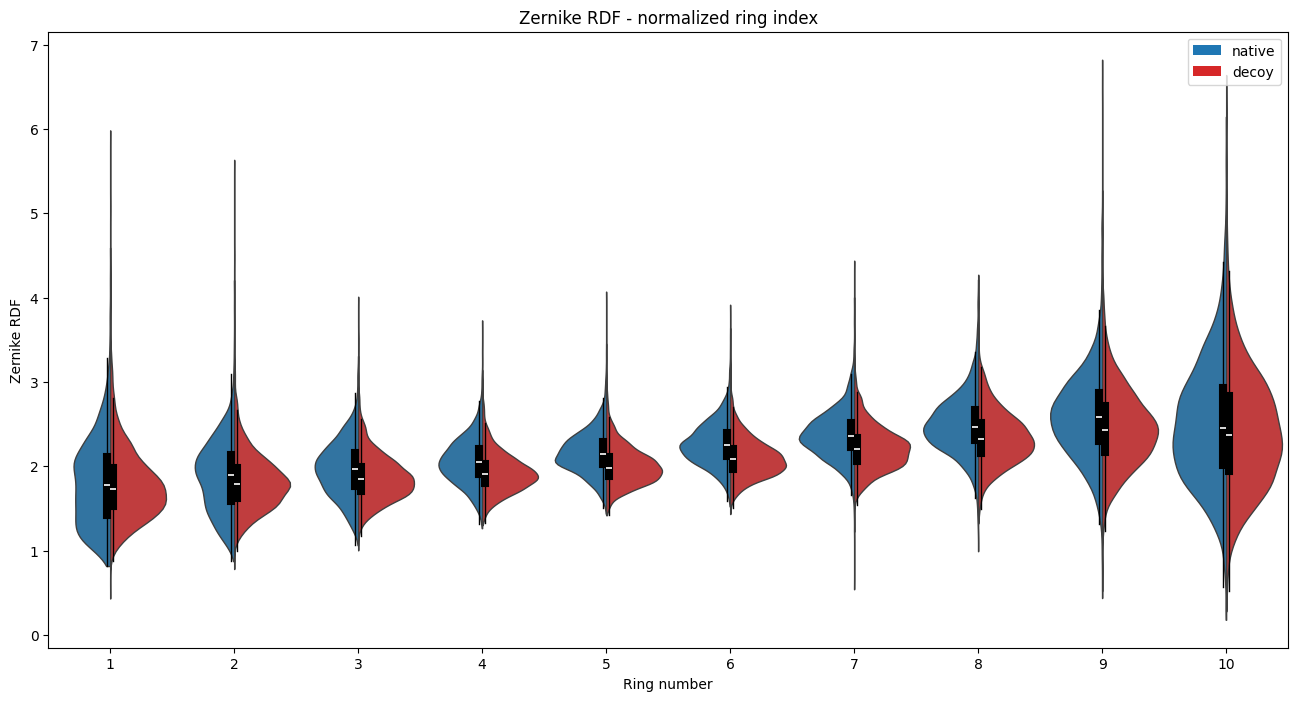

In [42]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.violinplot(
    data=zernike_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    split=True,
    inner=None,
    cut=0,
    width=0.9,
    linewidth=1,
    ax=ax,
)
sns.boxplot(
    data=zernike_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    width=0.10,
    whis=1.5,
    showfliers=False,
    showcaps=False,
    boxprops={'facecolor': 'black', 'edgecolor': 'black', 'zorder': 3},
    whiskerprops={'color': 'black', 'linewidth': 1.0},
    capprops={'color': 'black', 'linewidth': 0.0},
    medianprops={'color': 'white', 'linewidth': 1.2, 'zorder': 5},
    ax=ax,
)
legend = ax.get_legend()
if legend is not None:
    legend.remove()
ax.legend(handles=[
    mpatches.Patch(facecolor=palette['native'], label='native'),
    mpatches.Patch(facecolor=palette['decoy'], label='decoy'),
], title='')
ax.set_title('Zernike RDF - normalized ring index')
ax.set_xlabel('Ring number')
ax.set_ylabel('Zernike RDF')
fig.savefig('plots/zernike_rdf_normalized.pdf', bbox_inches='tight')
plt.show()

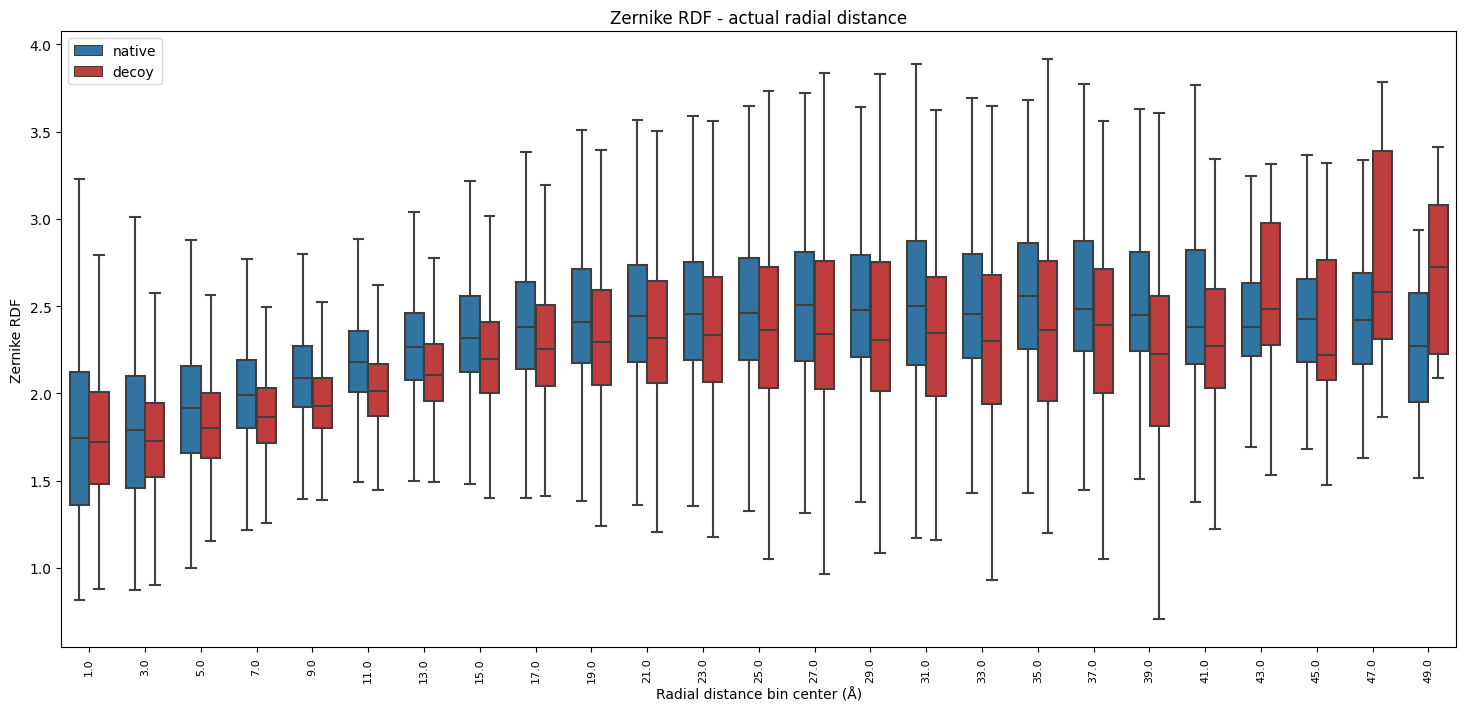

In [23]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=zernike_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    showfliers=False,
    width=0.7,
    ax=ax,
)
ax.set_title('Zernike RDF - actual radial distance')
ax.set_xlabel('Radial distance bin center (Å)')
ax.set_ylabel('Zernike RDF')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.legend(title='')
fig.savefig('plots/zernike_rdf_radial.pdf', bbox_inches='tight')
plt.show()

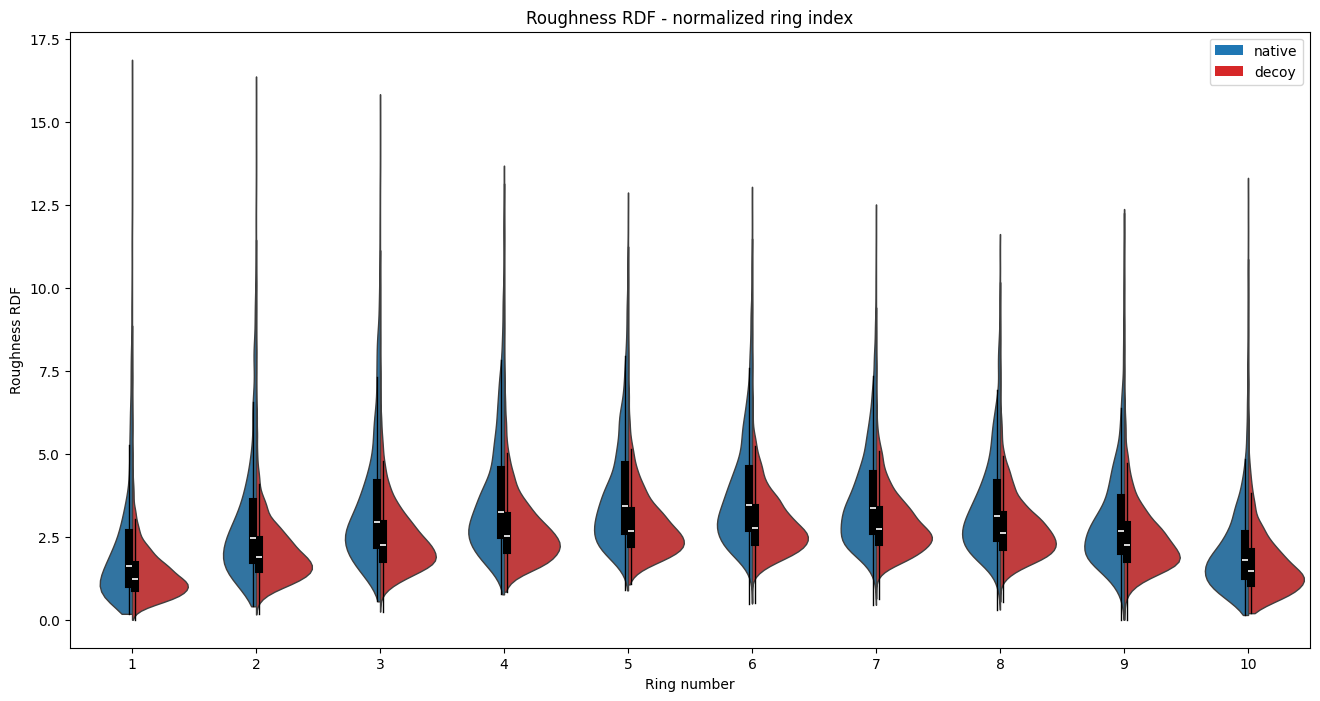

In [43]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.violinplot(
    data=roughness_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    split=True,
    inner=None,
    cut=0,
    width=0.9,
    linewidth=1,
    ax=ax,
)
sns.boxplot(
    data=roughness_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    width=0.10,
    whis=1.5,
    showfliers=False,
    showcaps=False,
    boxprops={'facecolor': 'black', 'edgecolor': 'black', 'zorder': 3},
    whiskerprops={'color': 'black', 'linewidth': 1.0},
    capprops={'color': 'black', 'linewidth': 0.0},
    medianprops={'color': 'white', 'linewidth': 1.2, 'zorder': 5},
    ax=ax,
)
legend = ax.get_legend()
if legend is not None:
    legend.remove()
ax.legend(handles=[
    mpatches.Patch(facecolor=palette['native'], label='native'),
    mpatches.Patch(facecolor=palette['decoy'], label='decoy'),
], title='')
ax.set_title('Roughness RDF - normalized ring index')
ax.set_xlabel('Ring number')
ax.set_ylabel('Roughness RDF')
fig.savefig('plots/roughness_rdf_normalized.pdf', bbox_inches='tight')
plt.show()

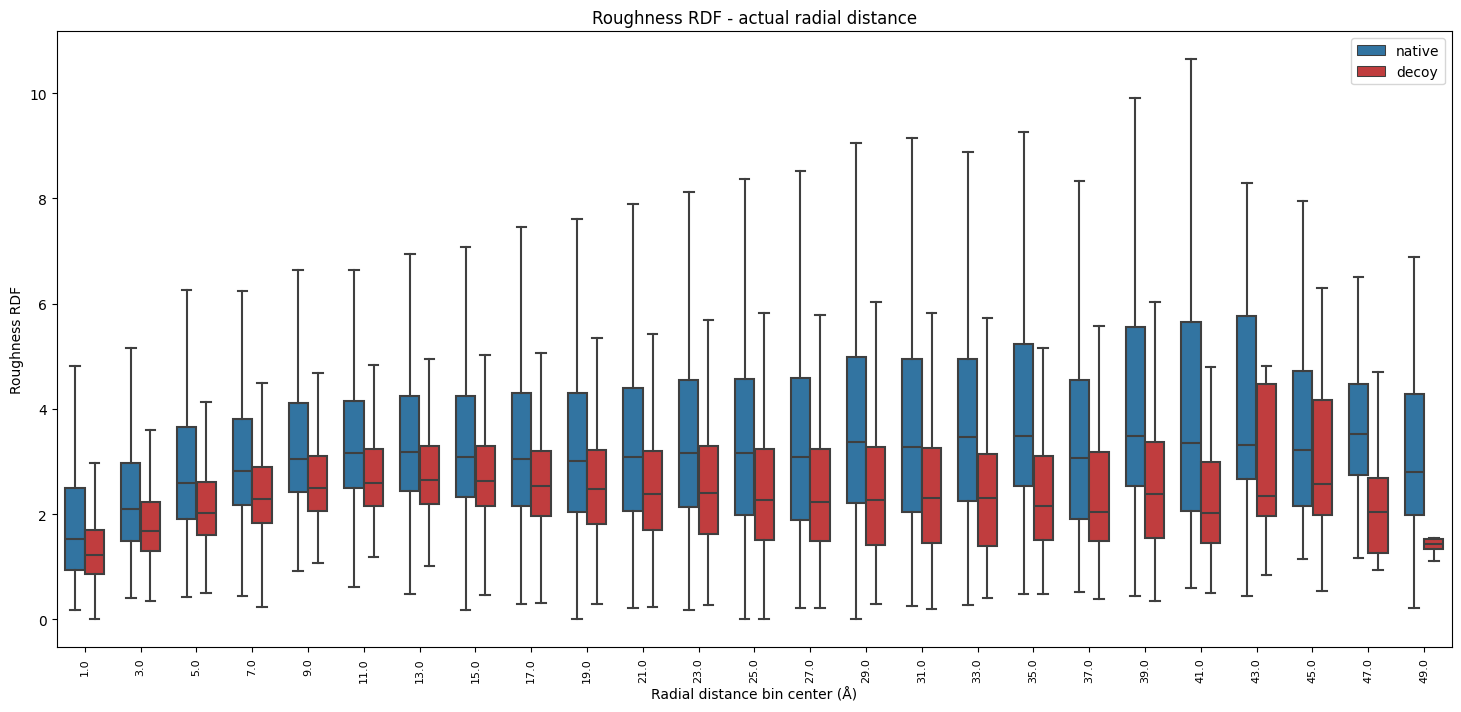

In [25]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=roughness_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    showfliers=False,
    width=0.7,
    ax=ax,
)
ax.set_title('Roughness RDF - actual radial distance')
ax.set_xlabel('Radial distance bin center (Å)')
ax.set_ylabel('Roughness RDF')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.legend(title='')
fig.savefig('plots/roughness_rdf_radial.pdf', bbox_inches='tight')
plt.show()